In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

In [37]:
# Load clean data
ipl = pd.read_csv('E:\\ipl_dataset1\\ipl_clean.csv', 
                   low_memory=False)

# Fix season format 
ipl['season'] = ipl['season'].astype(str).str[:4].astype(int)

# Remove incomplete 2026 season
ipl = ipl[ipl['season'] != 2026]

# Save fixes permanently to CSV
ipl.to_csv('E:\\ipl_dataset1\\ipl_clean.csv', index=False)
print("Data loaded and fixed!")

# Create match level dataframe
matches = ipl.drop_duplicates(subset='match_id')
print("Total matches:", len(matches))
print("Seasons:", sorted(ipl['season'].unique()))

Data loaded and fixed!
Total matches: 1169
Seasons: [np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [22]:
matches = ipl.drop_duplicates(subset='match_id')

print("Total balls:", len(ipl))
print("Total matches:", len(matches))
print("\nWin outcome values:")
print(matches['win_outcome'].unique())

Total balls: 278205
Total matches: 1169

Win outcome values:
['140 runs' '33 runs' '9 wickets' '5 wickets' '6 wickets' '6 runs'
 '3 wickets' '66 runs' '7 wickets' '10 wickets' '4 wickets' '13 runs'
 '10 runs' '45 runs' '8 wickets' '9 runs' '3 runs' '29 runs' '5 runs'
 '18 runs' '23 runs' '12 runs' '65 runs' '25 runs' '1 runs' '14 runs'
 '41 runs' '105 runs' '19 runs' '75 runs' '92 runs' '11 runs' '24 runs'
 'In Progress' '27 runs' '38 runs' '8 runs' '78 runs' '16 runs' '53 runs'
 '2 wickets' '2 runs' '4 runs' '31 runs' '55 runs' '98 runs' '34 runs'
 '36 runs' '17 runs' '39 runs' '40 runs' '67 runs' '63 runs' '37 runs'
 '57 runs' '35 runs' '22 runs' '21 runs' '48 runs' '26 runs' '20 runs'
 '85 runs' '32 runs' '76 runs' '111 runs' '82 runs' '43 runs' '58 runs'
 '28 runs' '74 runs' '42 runs' '59 runs' '46 runs' '7 runs' '47 runs'
 '86 runs' '44 runs' '87 runs' '130 runs' '15 runs' '60 runs' '77 runs'
 '30 runs' '50 runs' '93 runs' '72 runs' '62 runs' '97 runs' '138 runs'
 '1 wickets' '71 

In [23]:
print(matches['match_won_by'].unique())
print("\n")
print(matches[['batting_team', 'bowling_team', 
               'match_won_by', 'win_outcome']].head(10))

['Kolkata Knight Riders' 'Chennai Super Kings' 'Delhi Daredevils'
 'Royal Challengers Bangalore' 'Rajasthan Royals' 'Kings XI Punjab'
 'Deccan Chargers' 'Mumbai Indians' 'Unknown' 'Pune Warriors'
 'Kochi Tuskers Kerala' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Gujarat Lions' 'Rising Pune Supergiant' 'Delhi Capitals' 'Punjab Kings'
 'Gujarat Titans' 'Lucknow Super Giants' 'Royal Challengers Bengaluru']


               batting_team                 bowling_team  \
0     Kolkata Knight Riders  Royal Challengers Bengaluru   
225     Chennai Super Kings                 Punjab Kings   
473        Rajasthan Royals               Delhi Capitals   
692          Mumbai Indians  Royal Challengers Bengaluru   
938     Sunrisers Hyderabad        Kolkata Knight Riders   
1178           Punjab Kings             Rajasthan Royals   
1419    Sunrisers Hyderabad               Delhi Capitals   
1624    Chennai Super Kings               Mumbai Indians   
1879    Sunrisers Hyderabad             Raja

In [24]:
ipl['match_won_by'] = ipl['match_won_by'].str.replace(
    'Royal Challengers Bangalore',
    'Royal Challengers Bengaluru'
)
ipl['match_won_by'] = ipl['match_won_by'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
})

matches = ipl.drop_duplicates(subset='match_id')
print("Fixed Unique winners:", matches['match_won_by'].nunique())

Fixed Unique winners: 15


In [25]:
wins = matches[matches['match_won_by'] != 'Unknown'].groupby(
    'match_won_by').size().reset_index(name='wins')

# Count total matches per team
total = pd.concat([
    matches[['batting_team']].rename(columns={'batting_team':'team'}),
    matches[['bowling_team']].rename(columns={'bowling_team':'team'})
]).groupby('team').size().reset_index(name='total_matches')

# Merge and calculate win rate
win_rate = wins.merge(total, left_on='match_won_by', right_on='team')
win_rate['win_rate'] = (win_rate['wins'] / 
                         win_rate['total_matches'] * 100).round(2)
win_rate = win_rate.sort_values('win_rate', ascending=False)

print(win_rate[['team', 'wins', 'total_matches', 'win_rate']])

                           team  wins  total_matches  win_rate
3                Gujarat Titans    37             60     61.67
0           Chennai Super Kings   142            252     56.35
7                Mumbai Indians   151            277     54.51
6          Lucknow Super Giants    30             58     51.72
5         Kolkata Knight Riders   135            264     51.14
11      Rising Pune Supergiants    15             30     50.00
12  Royal Challengers Bengaluru   132            270     48.89
10             Rajasthan Royals   114            235     48.51
9                  Punjab Kings   119            264     45.08
13          Sunrisers Hyderabad   122            271     45.02
1                Delhi Capitals   118            267     44.19
2                 Gujarat Lions    13             30     43.33
4          Kochi Tuskers Kerala     6             14     42.86
8                 Pune Warriors    12             46     26.09


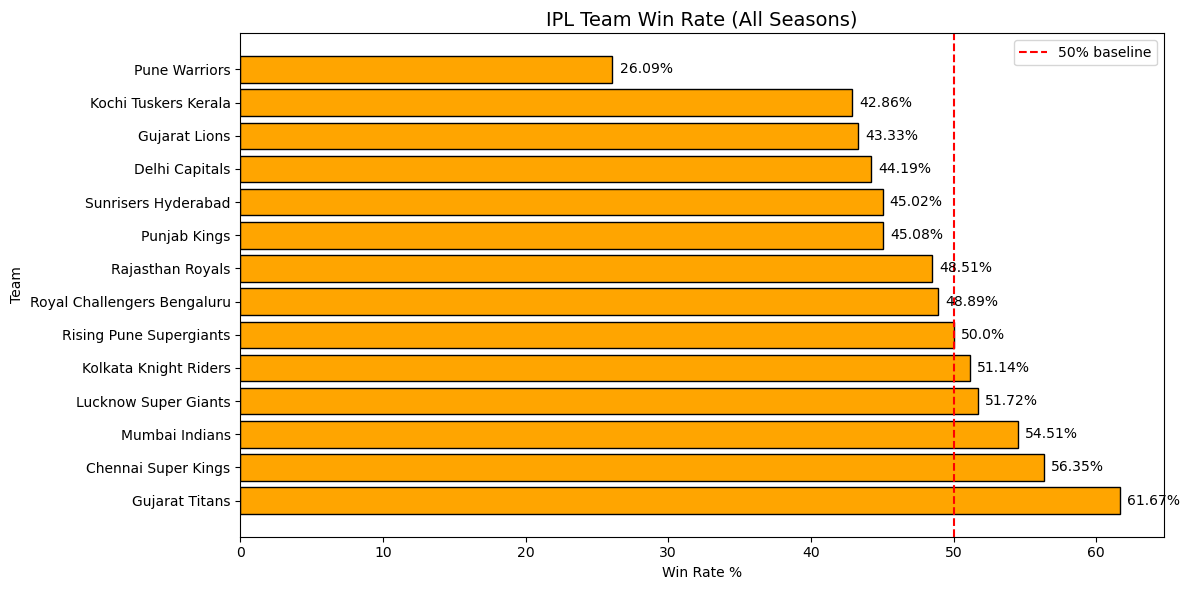

In [26]:
import os
os.makedirs('E:\\ipl_dataset1\\visuals', exist_ok=True)

plt.figure(figsize=(12,6))


plt.barh(win_rate['team'], win_rate['win_rate'], 
         color='orange', edgecolor='black')


plt.axvline(x=50, color='red', linestyle='--', 
            label='50% baseline')


for index, value in enumerate(win_rate['win_rate']):
    plt.text(value + 0.5, index, f'{value}%', va='center')

plt.title('IPL Team Win Rate (All Seasons)', fontsize=14)
plt.xlabel('Win Rate %')
plt.ylabel('Team')
plt.legend()
plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\win_rate.png', dpi=150)
plt.show()

In [27]:
toss_impact = matches.copy()


toss_impact['toss_match_win'] = (
    toss_impact['toss_winner'] == toss_impact['match_won_by']
)


toss_win_pct = toss_impact['toss_match_win'].value_counts(
                normalize=True) * 100
print(toss_win_pct.round(2))

toss_match_win
False    62.28
True     37.72
Name: proportion, dtype: float64


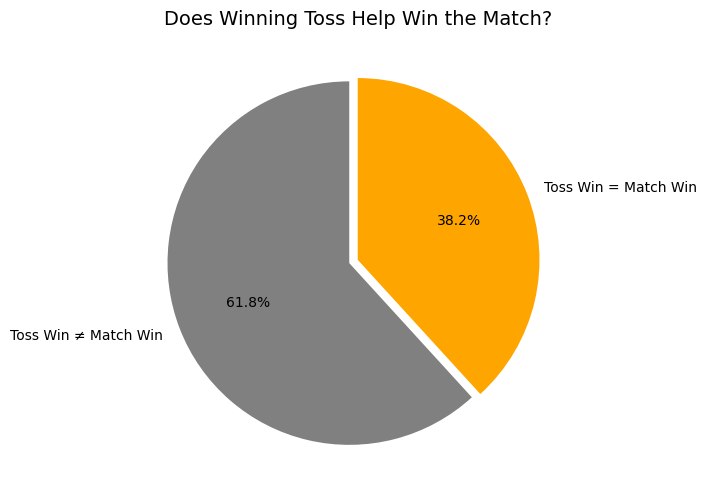

In [28]:
labels = ['Toss Win ≠ Match Win', 'Toss Win = Match Win']
sizes = [61.78, 38.22]

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=['grey', 'orange'],
        explode=(0.05, 0),
        startangle=90)
plt.title('Does Winning Toss Help Win the Match?', fontsize=14)
plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\toss_impact.png', dpi=150)
plt.show()

In [29]:
# Top 10 venues by number of matches
venue_matches = matches.groupby('venue').size()\
                .reset_index(name='total_matches')\
                .sort_values('total_matches', ascending=False)\
                .head(10)

print(venue_matches)

                                         venue  total_matches
14                                Eden Gardens             77
56                            Wankhede Stadium             73
23                       M Chinnaswamy Stadium             65
16                            Feroz Shah Kotla             60
57                    Wankhede Stadium, Mumbai             52
43   Rajiv Gandhi International Stadium, Uppal             49
27             MA Chidambaram Stadium, Chepauk             48
47                      Sawai Mansingh Stadium             47
13         Dubai International Cricket Stadium             46
41  Punjab Cricket Association Stadium, Mohali             35


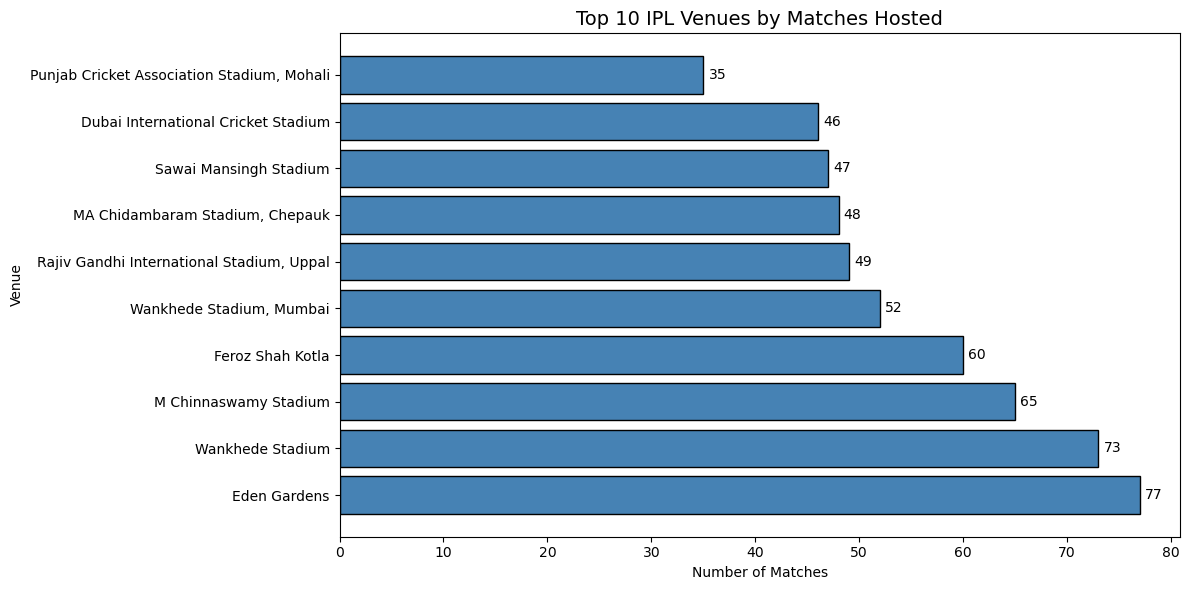

In [30]:
plt.figure(figsize=(12,6))
plt.barh(venue_matches['venue'], 
         venue_matches['total_matches'],
         color='steelblue', edgecolor='black')

# Add value labels
for index, value in enumerate(venue_matches['total_matches']):
    plt.text(value + 0.5, index, str(value), va='center')

plt.title('Top 10 IPL Venues by Matches Hosted', fontsize=14)
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\venue_matches.png', dpi=150)
plt.show()

In [31]:
# What do teams choose after winning toss?
toss_decision = matches.groupby('toss_decision').size()\
                .reset_index(name='count')
print(toss_decision)

  toss_decision  count
0           bat    405
1         field    764


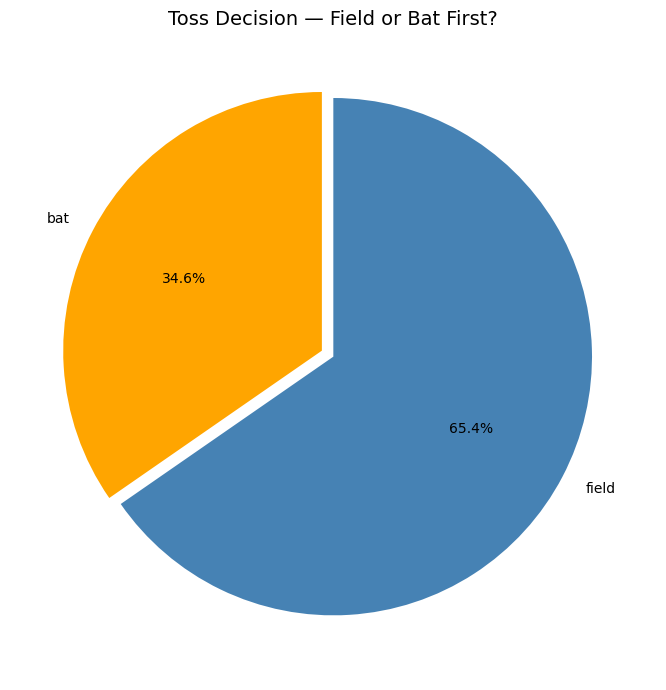

In [32]:
plt.figure(figsize=(7,7))
plt.pie(toss_decision['count'], 
        labels=toss_decision['toss_decision'],
        autopct='%1.1f%%',
        colors=['orange', 'steelblue'],
        explode=(0.05, 0),
        startangle=90)
plt.title('Toss Decision — Field or Bat First?', fontsize=14)
plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\toss_decision.png', dpi=150)
plt.show()

In [33]:
# Do teams win more by batting or fielding first?
decision_win = matches[matches['match_won_by'] != 'Unknown'].copy()
decision_win['won'] = (
    decision_win['toss_winner'] == decision_win['match_won_by']
)

result = decision_win.groupby('toss_decision')['won']\
         .mean() * 100
print(result.round(2))

toss_decision
bat      35.10
field    40.27
Name: won, dtype: float64


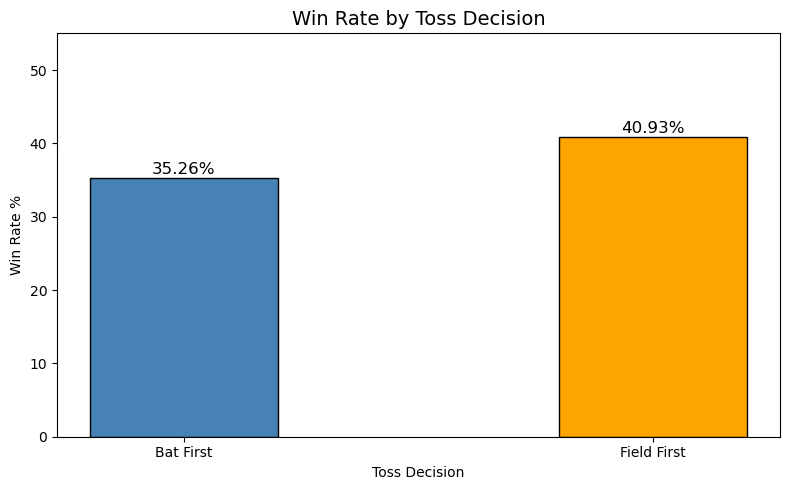

In [34]:
plt.figure(figsize=(8,5))
plt.bar(['Bat First', 'Field First'], 
        [35.26, 40.93],
        color=['steelblue', 'orange'],
        edgecolor='black',
        width=0.4)

# Add value labels
plt.text(0, 35.26 + 0.5, '35.26%', ha='center', fontsize=12)
plt.text(1, 40.93 + 0.5, '40.93%', ha='center', fontsize=12)

plt.title('Win Rate by Toss Decision', fontsize=14)
plt.xlabel('Toss Decision')
plt.ylabel('Win Rate %')
plt.ylim(0, 55)
plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\toss_decision_winrate.png', 
            dpi=150)
plt.show()

In [38]:
# Focus on top 5 consistent teams only
top5_teams = ['Mumbai Indians', 'Chennai Super Kings', 
              'Kolkata Knight Riders', 'Royal Challengers Bengaluru',
              'Rajasthan Royals']

# Total matches per team per season
total_season = pd.concat([
    matches[['season', 'batting_team']].rename(
        columns={'batting_team': 'team'}),
    matches[['season', 'bowling_team']].rename(
        columns={'bowling_team': 'team'})
]).groupby(['season', 'team']).size().reset_index(name='total')

# Wins per team per season
wins_season = matches[
    matches['match_won_by'] != 'Unknown'
].groupby(['season', 'match_won_by']).size()\
 .reset_index(name='wins')

# Merge and calculate win rate
season_winrate = wins_season.merge(
    total_season,
    left_on=['season', 'match_won_by'],
    right_on=['season', 'team']
)
season_winrate['win_rate'] = (
    season_winrate['wins'] / season_winrate['total'] * 100
).round(2)

# Filter top 5 teams
season_winrate = season_winrate[
    season_winrate['team'].isin(top5_teams)
]
print(season_winrate.head(10))

    season           match_won_by  wins                   team  total  \
0     2007    Chennai Super Kings     9    Chennai Super Kings     16   
1     2007  Kolkata Knight Riders     6  Kolkata Knight Riders     13   
2     2007         Mumbai Indians     7         Mumbai Indians     14   
3     2007       Rajasthan Royals    13       Rajasthan Royals     16   
4     2009    Chennai Super Kings    17    Chennai Super Kings     30   
5     2009  Kolkata Knight Riders    10  Kolkata Knight Riders     27   
6     2009         Mumbai Indians    16         Mumbai Indians     29   
7     2009       Rajasthan Royals    11       Rajasthan Royals     27   
8     2011    Chennai Super Kings    11    Chennai Super Kings     16   
10    2011  Kolkata Knight Riders     8  Kolkata Knight Riders     15   

    win_rate  
0      56.25  
1      46.15  
2      50.00  
3      81.25  
4      56.67  
5      37.04  
6      55.17  
7      40.74  
8      68.75  
10     53.33  


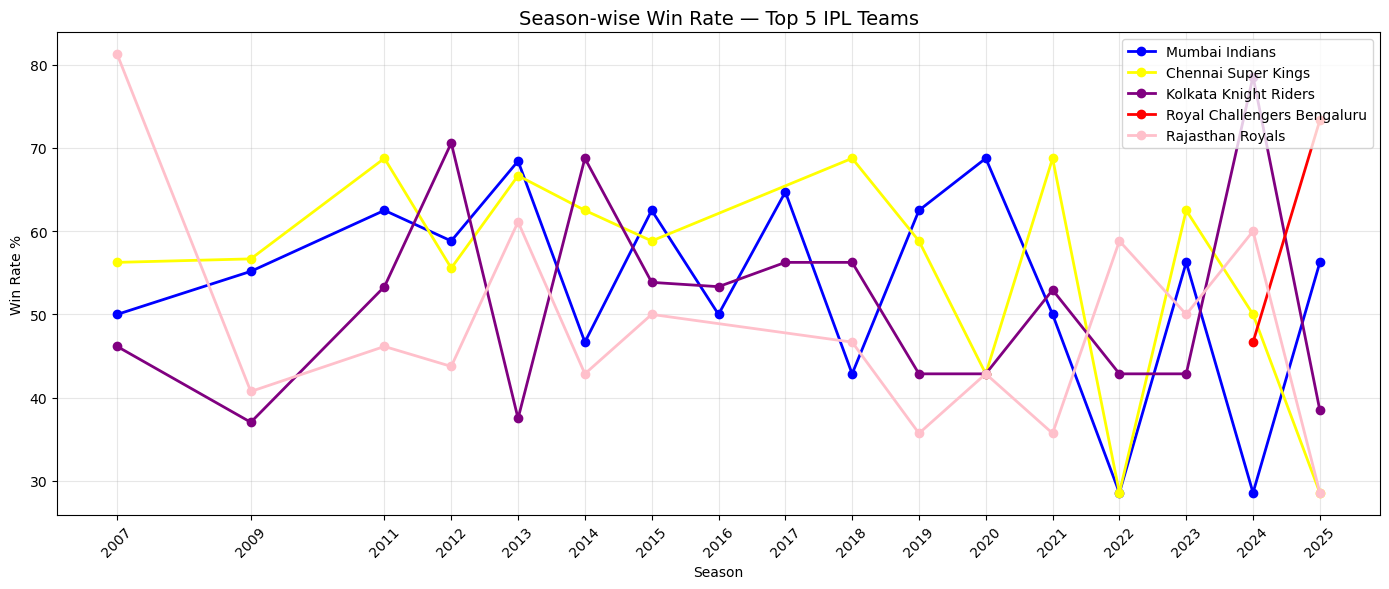

In [39]:
plt.figure(figsize=(14, 6))

colors = ['blue', 'yellow', 'purple', 'red', 'pink']

for i, team in enumerate(top5_teams):
    team_data = season_winrate[season_winrate['team'] == team]
    plt.plot(team_data['season'], team_data['win_rate'],
             marker='o', label=team, color=colors[i], linewidth=2)

plt.title('Season-wise Win Rate — Top 5 IPL Teams', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Win Rate %')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Fix x-axis to show only whole years
seasons = sorted(season_winrate['season'].unique())
plt.xticks(seasons, rotation=45)

plt.tight_layout()
plt.savefig('E:\\ipl_dataset1\\visuals\\season_trends.png', dpi=150)
plt.show()


In [40]:
# Run this at end of today's notebook
ipl.to_csv('E:\\ipl_dataset1\\ipl_clean.csv', index=False)
print("All progress saved!")

All progress saved!
